In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)

In [2]:
foldername = '/home/edavenport/analysis/vel-assim-manuscript/forecasts/results_figs/'

In [10]:
import pandas as pd
import numpy as np

# ═══════════════════════════════════════════════════════════════════
#  FORECAST PARAMETERS — only change start_date to switch forecasts
# ═══════════════════════════════════════════════════════════════════
start_date = pd.Timestamp('2013-05-01')

# Data directories (auto-constructed from start_date; verify for 2012 runs)
month_str = start_date.strftime('%b').lower()   # e.g. 'may', 'jul'
day_str   = start_date.strftime('%d')            # e.g. '01'
year_str  = start_date.strftime('%Y')            # e.g. '2013', '2012'

# 2013: /data/SO3/averdy/TPOSE6/{month}{year}/diags_daily/
# 2012: /data/SO6/TPOSE_diags/tpose6/{month}{year}/diags/  ← verify suffix
noTAO_data_dir         = f'/data/SO3/averdy/TPOSE6/{month_str}{year_str}/diags_daily/'
noTAO_forecast_data_dir = f'/data/SO3/edavenport/tpose6/forecasts/{month_str}{day_str}{year_str}_tpose_noVel/'
vel_forecast_data_dir  = f'/data/SO3/edavenport/tpose6/forecasts/{month_str}{day_str}{year_str}/'

# ── Derived quantities (do not edit below) ───────────────────────
end_date        = start_date + pd.DateOffset(months=4) - pd.Timedelta(days=1)
n_forecast_days = (end_date - start_date).days   # e.g. 122 for May 1–Aug 31
n_eval          = n_forecast_days
eval_start_date = start_date

# TPOSE loading: range(itPerFile, itPerFile*num_diags, itPerFile) → n_forecast_days steps
ref_date  = start_date.strftime('%Y-%m-%d')
itPerFile = 72
num_diags = n_forecast_days + 1

# Evaluation slice and x-axis
eval_slice = slice(0, n_forecast_days)
days       = np.arange(1, n_forecast_days + 1)   # day 1 = start_date

# Calendar months spanned by the evaluation window (for climatology baseline)
eval_months = sorted({(eval_start_date + pd.Timedelta(days=i)).month for i in range(n_eval)})

# Month boundary day numbers and label centers (for figure)
month_starts_in_window = pd.date_range(
    start_date + pd.offsets.MonthBegin(1), end_date, freq='MS'
)
month_bounds = {ms.strftime('%b 1'): (ms - start_date).days + 1
                for ms in month_starts_in_window}

all_month_starts = [start_date] + list(month_starts_in_window)
month_centers = []
for i, ms in enumerate(all_month_starts):
    me = all_month_starts[i + 1] if i + 1 < len(all_month_starts) else end_date + pd.Timedelta(days=1)
    center_day = (ms - start_date).days + (me - ms).days // 2 + 1
    month_centers.append((ms.strftime('%b'), center_day))

print(f'Forecast     : {start_date.date()} → {end_date.date()} ({n_forecast_days} days)')
print(f'Eval months  : {eval_months}')
print(f'noTAO est dir: {noTAO_data_dir}')
print(f'noTAO fct dir: {noTAO_forecast_data_dir}')
print(f'Vel fct dir  : {vel_forecast_data_dir}')

Forecast     : 2013-05-01 → 2013-08-31 (122 days)
Eval months  : [5, 6, 7, 8]
noTAO est dir: /data/SO3/averdy/TPOSE6/may2013/diags_daily/
noTAO fct dir: /data/SO3/edavenport/tpose6/forecasts/may012013_tpose_noVel/
Vel fct dir  : /data/SO3/edavenport/tpose6/forecasts/may012013/


### Load TPOSE Estimates and Forecasts

In [11]:
import matplotlib.pyplot as plt
import cmocean.cm as cmo
import xarray as xr
from xmitgcm import open_mdsdataset
plt.rcParams['font.size'] = 14

prefix   = ['diag_surf']
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'
intervals = range(itPerFile, itPerFile * num_diags, itPerFile)

### TPOSE-noVel State Estimate
ds_tpose_noTAO = open_mdsdataset(
    data_dir=noTAO_data_dir, grid_dir=grid_dir,
    iters=intervals, prefix=prefix, ref_date=ref_date, delta_t=1200)
ds_tpose_noTAO['XC'] = ds_tpose_noTAO.XC.astype(float)
ds_tpose_noTAO['YC'] = ds_tpose_noTAO.YC.astype(float)
ds_tpose_noTAO['Z']  = ds_tpose_noTAO.Z.astype(float)
ds_tpose_noTAO['XG'] = ds_tpose_noTAO.XG.astype(float)
ds_tpose_noTAO['YG'] = ds_tpose_noTAO.YG.astype(float)

### TPOSE-noVel Forecast
ds_tpose_noTAO_forecast = open_mdsdataset(
    data_dir=noTAO_forecast_data_dir, grid_dir=grid_dir,
    iters=intervals, prefix=prefix, ref_date=ref_date, delta_t=1200)
ds_tpose_noTAO_forecast['XC'] = ds_tpose_noTAO_forecast.XC.astype(float)
ds_tpose_noTAO_forecast['YC'] = ds_tpose_noTAO_forecast.YC.astype(float)
ds_tpose_noTAO_forecast['Z']  = ds_tpose_noTAO_forecast.Z.astype(float)
ds_tpose_noTAO_forecast['XG'] = ds_tpose_noTAO_forecast.XG.astype(float)
ds_tpose_noTAO_forecast['YG'] = ds_tpose_noTAO_forecast.YG.astype(float)

## TPOSE-Vel Forecast
ds_tpose_vel_forecast = open_mdsdataset(
    data_dir=vel_forecast_data_dir, grid_dir=grid_dir,
    iters=intervals, prefix=prefix, ref_date=ref_date, delta_t=1200)
ds_tpose_vel_forecast['XC'] = ds_tpose_vel_forecast.XC.astype(float)
ds_tpose_vel_forecast['YC'] = ds_tpose_vel_forecast.YC.astype(float)
ds_tpose_vel_forecast['Z']  = ds_tpose_vel_forecast.Z.astype(float)
ds_tpose_vel_forecast['XG'] = ds_tpose_vel_forecast.XG.astype(float)
ds_tpose_vel_forecast['YG'] = ds_tpose_vel_forecast.YG.astype(float)

### Load AVISO climatology and GLORYS

Aviso is monthly climatology caculated from 2010 to 2020 (i.e.. it is the monthly mean and std deviation at each point over that time)

In [12]:
aviso = xr.open_dataset('forecasts/aviso_data/aviso_climatology_1993to2012.nc')
glorys = xr.open_mfdataset('/data/SO3/edavenport/tpose6/glorys_data/glorys_*.nc', combine='by_coords')

glory = glorys.sel(time=slice(start_date.strftime('%Y-%m-%d'), end_date.strftime('%Y-%m-%d')))

### Compare Skill

In [13]:
lonMin = 180
lonMax = 260
latMin = -10
latMax = 10
zMin = -500
zMax = 0

### SSH RMSE vs AVISO

In [14]:
# Load AVISO ADT (Absolute Dynamic Topography = total SSH) for comparison
# Convert longitude from -180:180 to 0:360 to match TPOSE convention
aviso_obs = xr.open_dataset('forecasts/aviso_data/aviso_equatorial_pacific.nc',
                             chunks={'time': 10})
aviso_obs = aviso_obs.assign_coords(longitude=(aviso_obs.longitude % 360)).sortby('longitude')

aviso_full = aviso_obs.adt.sel(
    time=slice(start_date.strftime('%Y-%m-%d'), end_date.strftime('%Y-%m-%d')),
    latitude=slice(latMin, latMax),
    longitude=slice(lonMin, lonMax)
).compute()

glorys_region = glorys.assign_coords(
    longitude=(glorys.longitude % 360)
).sortby('longitude')
glorys_full = glorys_region.zos.sel(
    time=slice(start_date.strftime('%Y-%m-%d'), end_date.strftime('%Y-%m-%d')),
    latitude=slice(latMin, latMax),
    longitude=slice(lonMin, lonMax)
).compute()

In [15]:
# ── Load TPOSE and interpolate AVISO/GLORYS to TPOSE grid ─────────────────────
def load_etan(ds):
    return ds.ETAN.sel(XC=slice(lonMin, lonMax), YC=slice(latMin, latMax)).isel(time=eval_slice).compute()

tpose_noTAO_eval         = load_etan(ds_tpose_noTAO)
tpose_noTAO_fct_eval     = load_etan(ds_tpose_noTAO_forecast)
tpose_vel_eval           = load_etan(ds_tpose_vel_forecast)

tpose_xc = tpose_noTAO_eval.XC.values
tpose_yc = tpose_noTAO_eval.YC.values

aviso_eval  = aviso_full.isel(time=eval_slice).interp(longitude=tpose_xc, latitude=tpose_yc, method='linear')
glorys_eval = glorys_full.isel(time=eval_slice).interp(longitude=tpose_xc, latitude=tpose_yc, method='linear')

# Remove a single scalar (domain + time mean) from each product to align reference levels
aviso_anom           = aviso_eval           - float(aviso_eval.mean())
tpose_noTAO_anom     = tpose_noTAO_eval     - float(tpose_noTAO_eval.mean())
tpose_noTAO_fct_anom = tpose_noTAO_fct_eval - float(tpose_noTAO_fct_eval.mean())
tpose_vel_anom       = tpose_vel_eval       - float(tpose_vel_eval.mean())
glorys_anom          = glorys_eval          - float(glorys_eval.mean())

# ── Latitude-weighted spatial RMSE ────────────────────────────────────────────
lat_weights = np.cos(np.deg2rad(tpose_yc))
lat_weights_2d = lat_weights[:, np.newaxis] * np.ones(len(tpose_xc))
lat_weights_norm = lat_weights_2d / np.nansum(lat_weights_2d)

def spatial_rmse(model_vals, obs_vals):
    """Weighted spatial RMSE; shape (n_time, n_lat, n_lon) → (n_time,)."""
    diff = model_vals - obs_vals
    return np.sqrt(np.nansum(diff**2 * lat_weights_norm, axis=(1, 2)))

aviso_vals           = aviso_anom.values
rmse_noTAO           = spatial_rmse(tpose_noTAO_anom.values,     aviso_vals)
rmse_noTAO_forecast  = spatial_rmse(tpose_noTAO_fct_anom.values, aviso_vals)
rmse_vel             = spatial_rmse(tpose_vel_anom.values,        aviso_vals)
rmse_glorys          = spatial_rmse(glorys_anom.values,           aviso_vals)

# Persistence: initial field (day 1) from each forecast held constant for all n_eval days
def persistence_rmse(anom):
    field = anom.isel(time=0).values
    return spatial_rmse(np.broadcast_to(field, (n_eval,) + field.shape), aviso_vals)

rmse_noTAO_fct_persistence = persistence_rmse(tpose_noTAO_fct_anom)
rmse_vel_persistence       = persistence_rmse(tpose_vel_anom)

# ── Climatology baseline: area-weighted mean of adt_std per calendar month ────
aviso_clim_conv = aviso.assign_coords(longitude=(aviso.longitude % 360)).sortby('longitude')
clim_region = aviso_clim_conv.adt_std.sel(
    latitude=slice(latMin, latMax), longitude=slice(lonMin, lonMax))

clim_lat_w = np.cos(np.deg2rad(clim_region.latitude.values))
clim_lat_w_2d = clim_lat_w[:, np.newaxis] * np.ones(len(clim_region.longitude))
clim_lat_w_norm = clim_lat_w_2d / np.nansum(clim_lat_w_2d)

month_baseline = {m: float(np.nansum(clim_region.sel(month=m).values * clim_lat_w_norm))
                  for m in eval_months}

eval_dates = pd.date_range(eval_start_date, periods=n_eval)
baseline_ts = np.array([month_baseline[d.month] for d in eval_dates])

for m in eval_months:
    print(f'Month {m} ADT std dev baseline: {month_baseline[m]*100:.2f} cm')

Month 5 ADT std dev baseline: 5.55 cm
Month 6 ADT std dev baseline: 5.65 cm
Month 7 ADT std dev baseline: 5.79 cm
Month 8 ADT std dev baseline: 6.20 cm


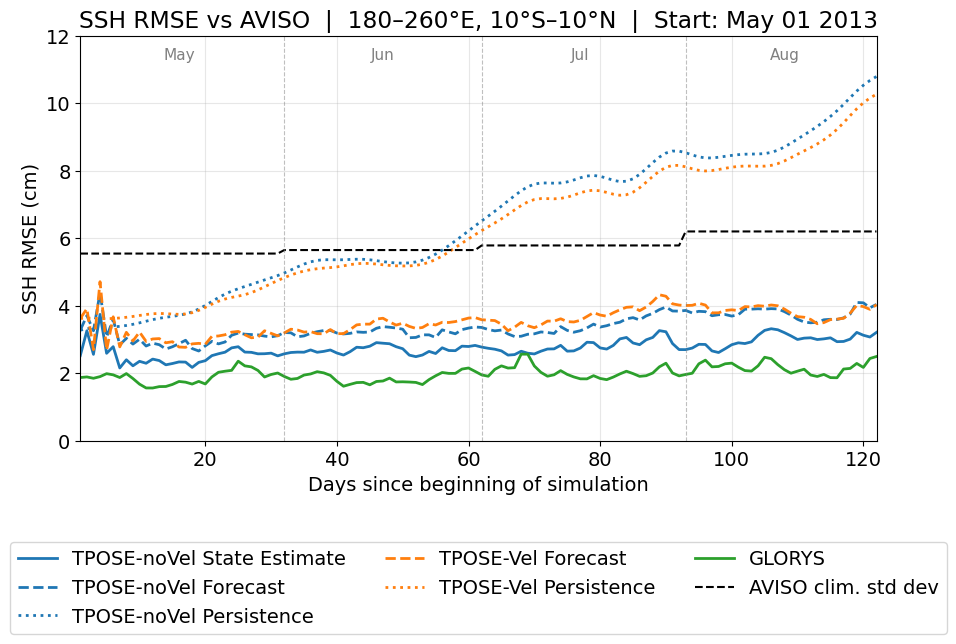

: 

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

ylim = (0, 12)

# Line styles: solid = state estimate, dashed = forecast, dotted = persistence
# Colors: C0 = TPOSE-noVel, C1 = TPOSE-Vel, C2 = GLORYS
ax.plot(days, rmse_noTAO * 100,               color='C0', lw=2, ls='-',  label='TPOSE-noVel State Estimate')
ax.plot(days, rmse_noTAO_forecast * 100,      color='C0', lw=2, ls='--', label='TPOSE-noVel Forecast')
ax.plot(days, rmse_noTAO_fct_persistence * 100, color='C0', lw=2, ls=':', label='TPOSE-noVel Persistence')
ax.plot(days, rmse_vel * 100,                 color='C1', lw=2, ls='--', label='TPOSE-Vel Forecast')
ax.plot(days, rmse_vel_persistence * 100,     color='C1', lw=2, ls=':',  label='TPOSE-Vel Persistence')
ax.plot(days, rmse_glorys * 100,              color='C2', lw=2, ls='-',  label='GLORYS')
ax.plot(days, baseline_ts * 100,              color='k',  lw=1.5, ls='--', label='AVISO clim. std dev')

for d in month_bounds.values():
    ax.axvline(d, color='gray', lw=0.8, linestyle='--', alpha=0.5)

for mname, xpos in month_centers:
    ax.text(xpos, ylim[1] * 0.97, mname, ha='center', va='top', color='gray', fontsize=11)

ax.set_xlabel('Days since beginning of simulation')
ax.set_ylabel('SSH RMSE (cm)')
ax.set_title(f'SSH RMSE vs AVISO  |  180–260°E, 10°S–10°N  |  Start: {start_date.strftime("%b %d %Y")}')
ax.set_xlim(days[0], days[-1])
ax.set_ylim(ylim)
ax.grid(alpha=0.3)
# Legend: 3 columns, entries fill row by row (noVel row, Vel row, GLORYS+baseline row)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=3, borderaxespad=0)

plt.tight_layout()
plt.savefig(foldername + f'ssh_rmse_vs_aviso_{month_str}{day_str}{year_str}.png', dpi=150, bbox_inches='tight')
plt.show()